In [ ]:
# STEP 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, confusion_matrix
)

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Neural Network
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

In [ ]:
# Load dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/AIML_Evaluation/Data/student_depression_balanced.csv")

In [ ]:
# Split features and target
X = df.drop("Depression", axis=1)
y = df["Depression"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (25387, 10), Test: (6347, 10)


In [ ]:
# STEP 3: Define Models (Best-Tuned from Each Category)

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_split=3, min_samples_leaf=2,
        criterion='entropy', class_weight='balanced_subsample', random_state=42
    ),

    "SVM": SVC(kernel='rbf', C=5.0, gamma='scale', probability=True, random_state=42),

    "Decision Tree": DecisionTreeClassifier(
        criterion='entropy', max_depth=8, min_samples_split=3, min_samples_leaf=2,
        class_weight='balanced', random_state=42
    ),

    "KNN": KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean'),

    "Logistic Regression": LogisticRegression(
        solver='liblinear', C=2.0, penalty='l2', class_weight='balanced', random_state=42
    ),
}

In [ ]:
# ==============================================================
# STEP 4: Evaluate Traditional ML Models
# ==============================================================
results_summary = {}

for name, model in models.items():
    print(f"\n=== Training {name} ===")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_pred_proba)

    results_summary[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "AUC": auc_score
    }

    print(f"Accuracy={acc:.4f} | Precision={prec:.4f} | Recall={rec:.4f} "
          f"| F1={f1:.4f} | AUC={auc_score:.4f}")




=== Training Random Forest ===
Accuracy=0.7953 | Precision=0.7721 | Recall=0.8380 | F1=0.8037 | AUC=0.8638

=== Training SVM ===
Accuracy=0.7819 | Precision=0.7491 | Recall=0.8478 | F1=0.7954 | AUC=0.8224

=== Training Decision Tree ===
Accuracy=0.7884 | Precision=0.7570 | Recall=0.8494 | F1=0.8005 | AUC=0.8515

=== Training KNN ===
Accuracy=0.7615 | Precision=0.7703 | Recall=0.7450 | F1=0.7574 | AUC=0.8258

=== Training Logistic Regression ===
Accuracy=0.7818 | Precision=0.7597 | Recall=0.8241 | F1=0.7906 | AUC=0.8448


In [ ]:
# STEP 5: Train & Evaluate MLP
# ======================================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

num_features = X_train.shape[1]
num_classes = 2  # Binary classification

mlp = Sequential([
    Dense(10, activation='relu', input_shape=(num_features,)),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

mlp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = mlp.fit(
    X_train_scaled, y_train, epochs=50, batch_size=10,
    validation_split=0.2, callbacks=[early_stop], verbose=0
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Evaluate
mlp_loss, mlp_acc = mlp.evaluate(X_test_scaled, y_test, verbose=0)
y_pred_proba_mlp = mlp.predict(X_test_scaled).ravel()
y_pred_mlp = (y_pred_proba_mlp >= 0.5).astype(int)

mlp_prec = precision_score(y_test, y_pred_mlp)
mlp_rec = recall_score(y_test, y_pred_mlp)
mlp_f1 = f1_score(y_test, y_pred_mlp)
mlp_auc = roc_auc_score(y_test, y_pred_proba_mlp)

results_summary["MLP Neural Net"] = {
    "Accuracy": mlp_acc,
    "Precision": mlp_prec,
    "Recall": mlp_rec,
    "F1-Score": mlp_f1,
    "AUC": mlp_auc
}

print(f"\n=== MLP Neural Net Results ===")
print(f"Accuracy={mlp_acc:.4f} | Precision={mlp_prec:.4f} | Recall={mlp_rec:.4f} | F1={mlp_f1:.4f} | AUC={mlp_auc:.4f}")

199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

=== MLP Neural Net Results ===
Accuracy=0.7848 | Precision=0.7591 | Recall=0.8342 | F1=0.7949 | AUC=0.8446


,Accuracy,Precision,Recall,F1-Score,AUC
Random Forest,0.795336,0.772067,0.838008,0.803687,0.863794
SVM,0.781944,0.749095,0.847778,0.795387,0.822364
Decision Tree,0.788404,0.757022,0.849354,0.800535,0.851476
KNN,0.761462,0.770283,0.745036,0.757450,0.825834
Logistic Regression,0.781787,0.759733,0.824141,0.790627,0.844762
MLP Neural Net,0.784780,0.759105,0.834226,0.794895,0.844554


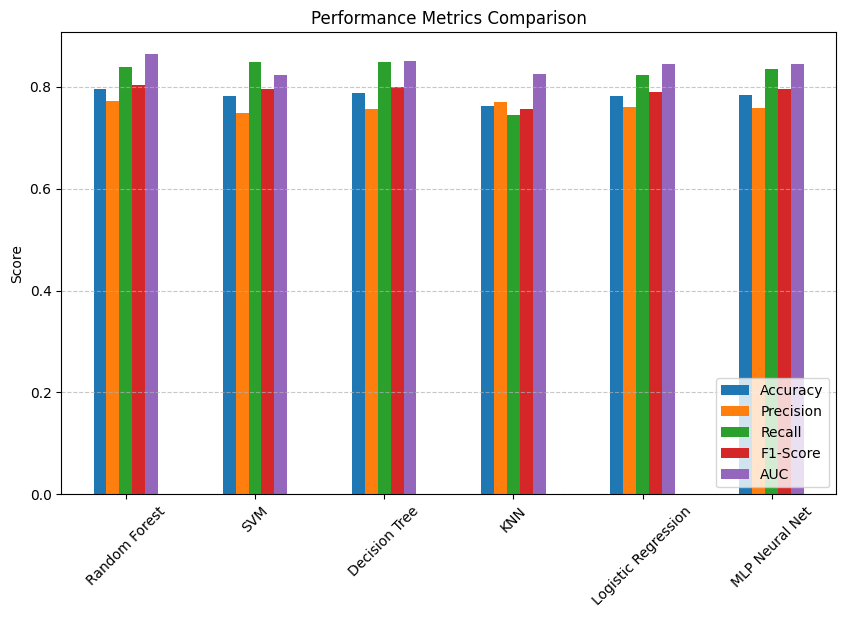

In [ ]:
# STEP 6: Compare Models Visually
# ======================================================================
results_df = pd.DataFrame(results_summary).T
display(results_df.style.background_gradient(cmap="Greens").set_caption("Model Performance Comparison"))

# Bar chart for metrics
results_df.plot(kind='bar', figsize=(10,6))
plt.title("Performance Metrics Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

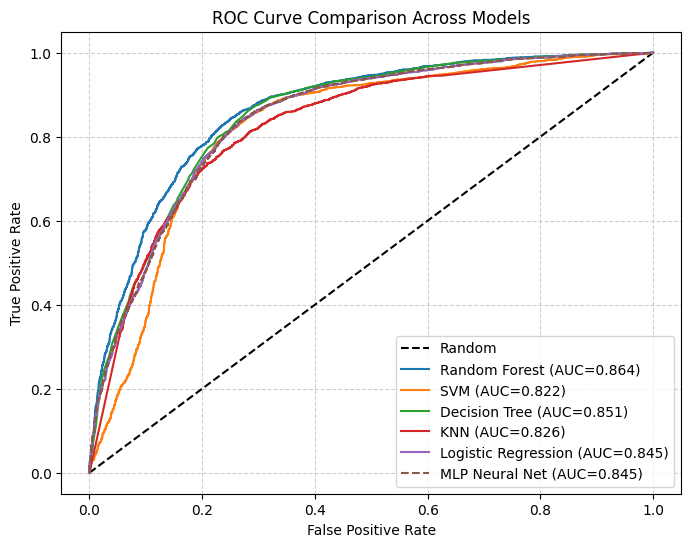

In [ ]:
# STEP 7: ROC Curve Comparison
# ======================================================================
plt.figure(figsize=(8,6))
plt.plot([0,1], [0,1], 'k--', label='Random')

for name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, y_pred_proba):.3f})")

# Add MLP
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_pred_proba_mlp)
plt.plot(fpr_mlp, tpr_mlp, label=f"MLP Neural Net (AUC={mlp_auc:.3f})", linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison Across Models')
plt.legend(loc='lower right')
plt.grid(linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# STEP 8: Print Final Summary
# ======================================================================
print("\n=== FINAL COMPARISON SUMMARY ===")
for name, metrics in results_summary.items():
    print(f"{name:<20}: Acc={metrics['Accuracy']:.4f} | Prec={metrics['Precision']:.4f} | "
          f"Rec={metrics['Recall']:.4f} | F1={metrics['F1-Score']:.4f} | AUC={metrics['AUC']:.4f}")

best_model_name = max(results_summary, key=lambda x: results_summary[x]['AUC'])
print(f"\n🏆 Best Overall Model: {best_model_name} (AUC = {results_summary[best_model_name]['AUC']:.4f})")


=== FINAL COMPARISON SUMMARY ===
Random Forest       : Acc=0.7953 | Prec=0.7721 | Rec=0.8380 | F1=0.8037 | AUC=0.8638
SVM                 : Acc=0.7819 | Prec=0.7491 | Rec=0.8478 | F1=0.7954 | AUC=0.8224
Decision Tree       : Acc=0.7884 | Prec=0.7570 | Rec=0.8494 | F1=0.8005 | AUC=0.8515
KNN                 : Acc=0.7615 | Prec=0.7703 | Rec=0.7450 | F1=0.7574 | AUC=0.8258
Logistic Regression : Acc=0.7818 | Prec=0.7597 | Rec=0.8241 | F1=0.7906 | AUC=0.8448
MLP Neural Net      : Acc=0.7848 | Prec=0.7591 | Rec=0.8342 | F1=0.7949 | AUC=0.8446

🏆 Best Overall Model: Random Forest (AUC = 0.8638)
